In [ ]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data=pd.read_csv("housing.csv")

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
data.dropna(inplace=True)
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
X=data.drop(["median_house_value"] , axis=1)
Y=data["median_house_value"]
X,Y

(       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
 0        -122.23     37.88                41.0        880.0           129.0   
 1        -122.22     37.86                21.0       7099.0          1106.0   
 2        -122.24     37.85                52.0       1467.0           190.0   
 3        -122.25     37.85                52.0       1274.0           235.0   
 4        -122.25     37.85                52.0       1627.0           280.0   
 ...          ...       ...                 ...          ...             ...   
 20635    -121.09     39.48                25.0       1665.0           374.0   
 20636    -121.21     39.49                18.0        697.0           150.0   
 20637    -121.22     39.43                17.0       2254.0           485.0   
 20638    -121.32     39.43                18.0       1860.0           409.0   
 20639    -121.24     39.37                16.0       2785.0           616.0   
 
        population  households  median

In [ ]:
#sns.heatmap(train_data.corr(), annot=True, cmap="YlGnBu")
#plt.figure(figsize=(15,8))

In [ ]:
from sklearn.model_selection import train_test_split
import random
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2)
random.seed(42)

#train data= both x_train and y_train
train_data=X_train.join(Y_train)
train_data


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
998,-121.80,37.69,17.0,3956.0,639.0,2222.0,662.0,5.4324,INLAND,215500.0
8074,-118.18,33.82,52.0,2618.0,472.0,943.0,440.0,3.7895,NEAR OCEAN,254000.0
15138,-116.92,32.82,16.0,2784.0,468.0,1458.0,465.0,4.0048,<1H OCEAN,184600.0
10135,-117.91,33.91,24.0,2249.0,379.0,1015.0,385.0,4.9766,<1H OCEAN,267100.0
18789,-122.37,40.39,12.0,3783.0,702.0,1970.0,639.0,3.3005,INLAND,98500.0
...,...,...,...,...,...,...,...,...,...,...
16955,-122.30,37.53,40.0,1833.0,308.0,751.0,306.0,6.0000,NEAR OCEAN,384200.0
18709,-122.40,40.58,43.0,1455.0,300.0,747.0,279.0,2.7857,INLAND,104200.0
8832,-118.37,34.09,33.0,3180.0,865.0,1347.0,841.0,4.0651,<1H OCEAN,500001.0
19606,-121.04,37.50,33.0,613.0,123.0,343.0,116.0,3.1875,INLAND,129200.0


In [ ]:
train_data["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     7253
INLAND        5177
NEAR OCEAN    2099
NEAR BAY      1813
ISLAND           4
Name: count, dtype: int64

In [ ]:
pd.get_dummies(train_data.ocean_proximity).astype(int)


,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
998,0,1,0,0,0
8074,0,0,0,0,1
15138,1,0,0,0,0
10135,1,0,0,0,0
18789,0,1,0,0,0
...,...,...,...,...,...
16955,0,0,0,0,1
18709,0,1,0,0,0
8832,1,0,0,0,0
19606,0,1,0,0,0


In [ ]:
train_data=train_data.join(pd.get_dummies(train_data.ocean_proximity).astype(int)).drop(["ocean_proximity"], axis=1)


In [ ]:
#train_data["bedroom_ratio"] = train_data["total_bedrooms"] / train_data["total_rooms"]
#train_data["rooms_per_household"] = train_data["total_rooms"] / train_data["households"]
#train_data["people_per_household"] = train_data["population"] / train_data["households"]

In [ ]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
998,-121.80,37.69,17.0,3956.0,639.0,2222.0,662.0,5.4324,215500.0,0,1,0,0,0
8074,-118.18,33.82,52.0,2618.0,472.0,943.0,440.0,3.7895,254000.0,0,0,0,0,1
15138,-116.92,32.82,16.0,2784.0,468.0,1458.0,465.0,4.0048,184600.0,1,0,0,0,0
10135,-117.91,33.91,24.0,2249.0,379.0,1015.0,385.0,4.9766,267100.0,1,0,0,0,0
18789,-122.37,40.39,12.0,3783.0,702.0,1970.0,639.0,3.3005,98500.0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16955,-122.30,37.53,40.0,1833.0,308.0,751.0,306.0,6.0000,384200.0,0,0,0,0,1
18709,-122.40,40.58,43.0,1455.0,300.0,747.0,279.0,2.7857,104200.0,0,1,0,0,0
8832,-118.37,34.09,33.0,3180.0,865.0,1347.0,841.0,4.0651,500001.0,1,0,0,0,0
19606,-121.04,37.50,33.0,613.0,123.0,343.0,116.0,3.1875,129200.0,0,1,0,0,0


<Axes: >

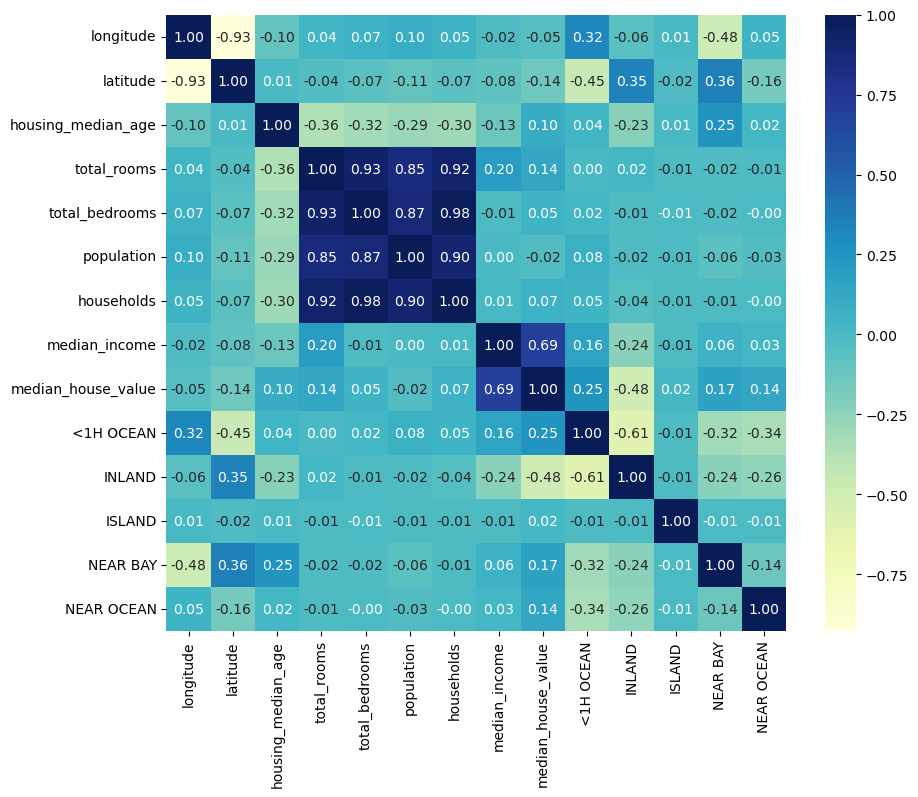

In [ ]:
corr=train_data.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap="YlGnBu")

<Axes: xlabel='latitude', ylabel='longitude'>

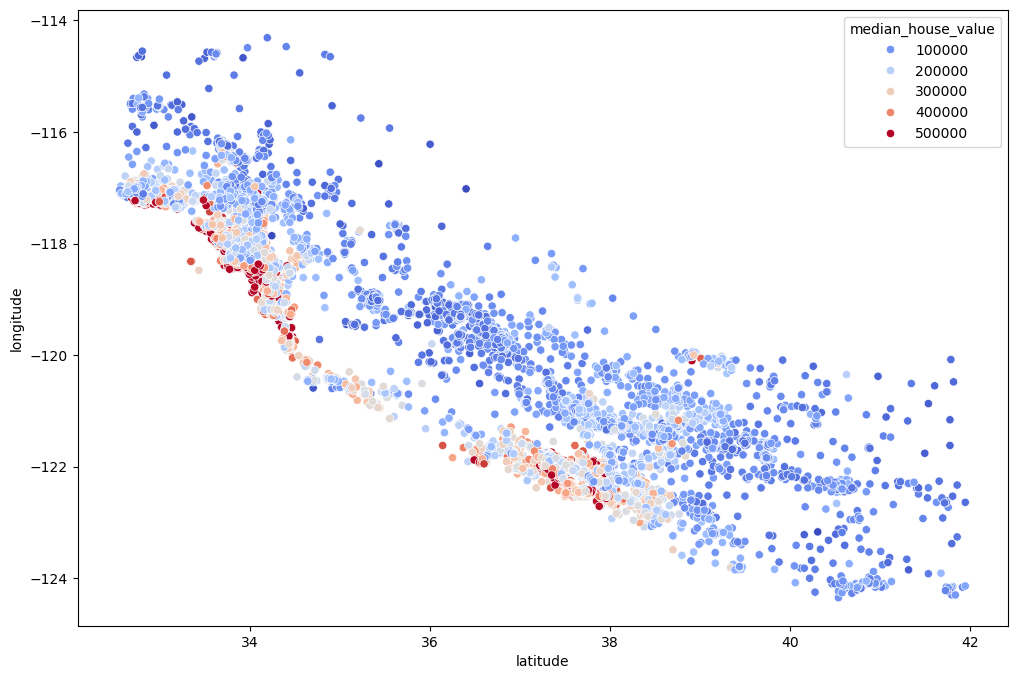

In [ ]:
plt.figure(figsize=(12,8))
sns.scatterplot(x="latitude", y="longitude", data=train_data, hue="median_house_value", palette="coolwarm")

In [ ]:

from sklearn.linear_model import LinearRegression

X_train, Y_train = train_data.drop(["median_house_value"],axis=1) , train_data["median_house_value"]
reg=LinearRegression()

#TRAINING THE DATA 
reg.fit(X_train, Y_train)


LinearRegression()

In [ ]:
X_train

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
998,-121.80,37.69,17.0,3956.0,639.0,2222.0,662.0,5.4324,0,1,0,0,0
8074,-118.18,33.82,52.0,2618.0,472.0,943.0,440.0,3.7895,0,0,0,0,1
15138,-116.92,32.82,16.0,2784.0,468.0,1458.0,465.0,4.0048,1,0,0,0,0
10135,-117.91,33.91,24.0,2249.0,379.0,1015.0,385.0,4.9766,1,0,0,0,0
18789,-122.37,40.39,12.0,3783.0,702.0,1970.0,639.0,3.3005,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
16955,-122.30,37.53,40.0,1833.0,308.0,751.0,306.0,6.0000,0,0,0,0,1
18709,-122.40,40.58,43.0,1455.0,300.0,747.0,279.0,2.7857,0,1,0,0,0
8832,-118.37,34.09,33.0,3180.0,865.0,1347.0,841.0,4.0651,1,0,0,0,0
19606,-121.04,37.50,33.0,613.0,123.0,343.0,116.0,3.1875,0,1,0,0,0


In [ ]:
# WE HAVE DONE FOR TRAIN DATA DO THE SAME FOR TEST DATA FROM COPY PASTE FROM ABOVE CELLS

test_data=X_test.join(Y_test)
pd.get_dummies(test_data.ocean_proximity).astype(int)
test_data=test_data.join(pd.get_dummies(test_data.ocean_proximity).astype(int)).drop(["ocean_proximity"], axis=1)
test_data = test_data.reindex(columns=train_data.columns, fill_value=0)

X_test, Y_test = test_data.drop(["median_house_value"],axis=1) , test_data["median_house_value"]
test_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
14718,-117.06,32.79,21.0,3787.0,492.0,1246.0,457.0,9.6023,391300.0,1,0,0,0,0
18370,-121.93,37.13,37.0,1150.0,203.0,511.0,179.0,5.7415,398500.0,1,0,0,0,0
19685,-121.61,39.14,44.0,2035.0,476.0,1030.0,453.0,1.4661,65200.0,0,1,0,0,0
17660,-121.89,37.28,32.0,4308.0,717.0,2002.0,695.0,4.1645,281900.0,1,0,0,0,0
20623,-121.37,39.03,32.0,1158.0,244.0,598.0,227.0,2.8235,65500.0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18400,-121.84,37.25,25.0,5939.0,989.0,3275.0,954.0,5.6488,234600.0,1,0,0,0,0
18089,-122.06,37.33,23.0,4507.0,751.0,2167.0,722.0,7.0102,500001.0,1,0,0,0,0
6310,-118.02,34.04,27.0,5640.0,1001.0,3538.0,978.0,5.0650,215400.0,1,0,0,0,0
4137,-118.18,34.12,45.0,2397.0,488.0,1569.0,471.0,4.2100,167900.0,1,0,0,0,0


In [ ]:
X_test

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
14718,-117.06,32.79,21.0,3787.0,492.0,1246.0,457.0,9.6023,1,0,0,0,0
18370,-121.93,37.13,37.0,1150.0,203.0,511.0,179.0,5.7415,1,0,0,0,0
19685,-121.61,39.14,44.0,2035.0,476.0,1030.0,453.0,1.4661,0,1,0,0,0
17660,-121.89,37.28,32.0,4308.0,717.0,2002.0,695.0,4.1645,1,0,0,0,0
20623,-121.37,39.03,32.0,1158.0,244.0,598.0,227.0,2.8235,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18400,-121.84,37.25,25.0,5939.0,989.0,3275.0,954.0,5.6488,1,0,0,0,0
18089,-122.06,37.33,23.0,4507.0,751.0,2167.0,722.0,7.0102,1,0,0,0,0
6310,-118.02,34.04,27.0,5640.0,1001.0,3538.0,978.0,5.0650,1,0,0,0,0
4137,-118.18,34.12,45.0,2397.0,488.0,1569.0,471.0,4.2100,1,0,0,0,0


In [ ]:
#from sklearn.metrics import accracy_score
#reg.score(X_test, Y_test)

In [ ]:
reg.predict(X_train)

array([216917.05743079, 264228.66568812, 200169.52401206, ...,
       286634.46372348, 142567.40913669, 242077.61521439])

In [ ]:

reg.score(X_test, Y_test)

0.6487595505339143

In [ ]:
#TRY WITH OTHER REGRESSORSSS
from sklearn.ensemble import RandomForestRegressor
Forest = RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_split=5, random_state=42)
Forest.fit(X_train, Y_train)


RandomForestRegressor(max_depth=10, min_samples_split=5, random_state=42)

In [ ]:
prediction=Forest.predict(X_train)
prediction

array([200585.51392824, 288071.83051945, 170665.98258243, ...,
       405599.74010597, 129143.56278372, 204882.5216753 ])

In [ ]:
Forest.score(X_test,Y_test)

0.7978267822998606

In [ ]:
from sklearn.metrics import mean_squared_error
preds = Forest.predict(X_test)
rmse = np.sqrt(mean_squared_error(Y_test, preds))
print(f"RMSE: ${rmse:,.0f}")
print(f"R² Score: {Forest.score(X_test, Y_test):.4f}")

RMSE: $51,257
R² Score: 0.7978


In [ ]:
import joblib


joblib.dump(Forest, "housing_price_model.pkl", compress=3)
joblib.dump(X_train.columns, "feature_columns.pkl")

['feature_columns.pkl']

In [ ]:
import os 
os.getcwd()

'c:\\Users\\prave\\OneDrive\\Desktop\\for_git'